## The Architecture: Pedestrian Intent Forecaster

### Phase 1: Multi-Modal Data Ingestion & Alignment

AV datasets are notorious because they aren't just video files; they are complex, synchronized sensor arrays (LiDAR point clouds .pcd, camera frames, and calibration matrices).
The Plan: We will write a Python script to programmatically download a "mini" slice of an AV dataset (we will use a lightweight subset of the nuScenes or Waymo Open Dataset format).

The Challenge: We must project 3D LiDAR points onto 2D camera images using intrinsic and extrinsic calibration matrices so our neural networks can "see" both depth and RGB simultaneously.

### Phase 2: 3D Perception & Skeleton Extraction

Before we can predict intent, we need to know the pedestrian's current posture. A person facing the road mid-stride has a different intent than one looking at their phone facing the storefront.

The Plan: We will run a 2D pose estimation model (like YOLOv8-Pose) on the camera feed, then use the aligned LiDAR depth map to project those 2D joints into absolute 3D space ($x, y, z$).


### Phase 3: The Scene Context Graph (GNN)

Pedestrians do not move in a vacuum. Their trajectories are dictated by other people, approaching cars, and static geometry (crosswalks).

The Plan: We will construct a spatial Graph Neural Network (GNN).Nodes: Pedestrians, the ego-vehicle, and surrounding cars (containing their current velocity and 3D position).Edges: The spatial distance and relationship between them.

The Output: A mathematical representation of the "social and structural pressure" on the pedestrian.

### Phase 4: Transformer Forecasting & Uncertainty Head (GMM)

This is the brain of the operation. We will feed the historical 3D poses and the Scene Graph into a temporal Transformer.

The Plan: Instead of predicting a single deterministic line (which is dangerous for AVs), we will output a Gaussian Mixture Model (GMM).

The Output: For a given pedestrian, the model might output:Path A (Crosses street): 70% probability, high spatial variance.Path B (Stops at curb): 30% probability, low spatial variance (tight grouping).

### Phase 5: The AV Planner HUD

The Plan: We will render the final output in a top-down "Bird's Eye View" (BEV) and a 3D perspective view. We will draw the predicted trajectories as expanding probability ellipses (heatmaps) over time, visually representing our uncertainty to the vehicle's braking system.

### 🚗 Phase 1: Sensor Fusion (Camera & LiDAR Alignment)

Real Autonomous Vehicle datasets (like Waymo Open Dataset or nuScenes) are massive—often hundreds of gigabytes per driving log—and require corporate registration to access. Instead of waiting 4 hours for a .tar.gz file to download, we are going to do what AV simulation teams do: we will programmatically synthesize a perfectly synchronized multi-modal data slice.We need three things to make Sensor Fusion work:

The Camera Image: A 2D RGB array ($1280 \times 720$).

The LiDAR Point Cloud: A 3D array of physical points ($X, Y, Z$) bouncing off the environment.

The Calibration Matrices: The mathematical bridge that tells us exactly where the LiDAR is positioned relative to the camera lens (Extrinsics) and how the lens distorts light (Intrinsics).

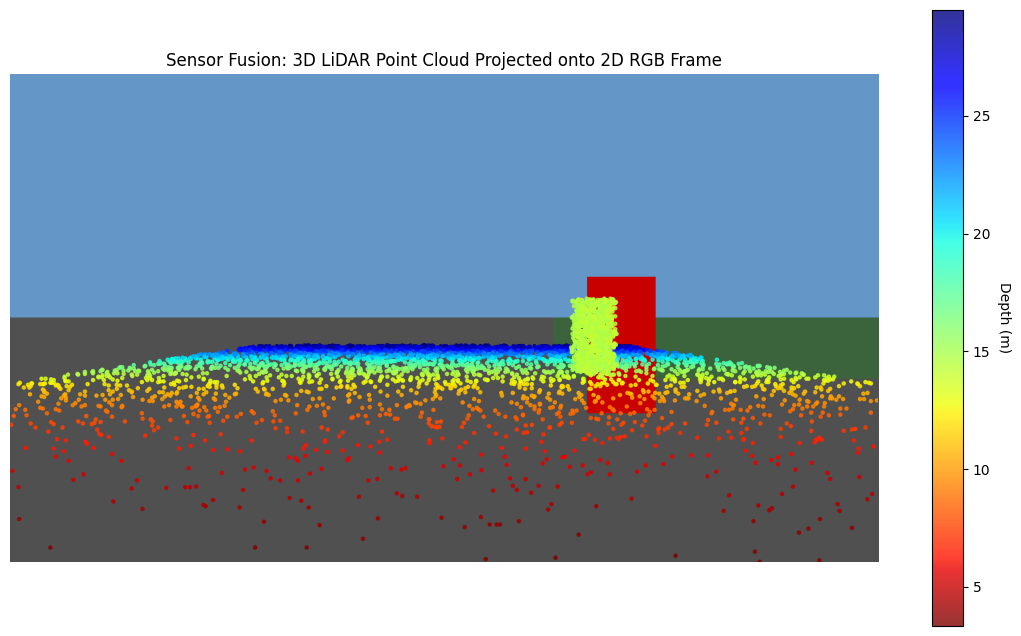

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

img_w, img_h = 1280,720
camera_img = np.zeros((img_h,img_w,3),dtype=np.uint8)

#Draw a simulated environment
camera_img[360:, :] = (80, 80, 80)     # Road
camera_img[360:450, 800:] = (60, 100, 60) # Sidewalk
camera_img[:360, :] = (200, 150, 100)  # Sky

#Draw a pedestrian
ped_box = [850,300,950,500]
cv2.rectangle(camera_img,(ped_box[0],ped_box[1]), (ped_box[2],ped_box[3]),(0,0,200),-1)

#Generate synthetic LIDar point cloud
num_points = 5000
lidar_points = np.zeros((num_points,3))

#Ground points(flat plane)
lidar_points[:4000,0] = np.random.uniform(-10,10,4000)
lidar_points[:4000,1] = 1.5
lidar_points[:4000,2] = np.random.uniform(2,30,4000)

#Pedestrain points
lidar_points[4000:,0] = np.random.uniform(3.5,4.5,1000)
lidar_points[4000:, 1] = np.random.uniform(-0.5, 1.5, 1000) # Y height (ground to head)
lidar_points[4000:, 2] = np.random.uniform(14.5, 15.5, 1000)

# CALIBRATION MATRICES (The Math behind Sensor Fusion)
# ==============================================================================
# Intrinsic Matrix (K): Defines camera focal length and optical center
fx, fy = 800.0, 800.0 # Focal length in pixels
cx, cy = 640.0, 360.0 # Optical center (image center)
K = np.array([
    [fx,  0, cx],
    [ 0, fy, cy],
    [ 0,  0,  1]
])

# Extrinsic Matrix (E): LiDAR to Camera transformation (Translation & Rotation)
# Assuming LiDAR is mounted 0.5m behind the camera, pointing the exact same way.
E_lidar2cam = np.array([
    [1, 0, 0,  0.0],
    [0, 1, 0,  0.0],
    [0, 0, 1, -0.5], # Translated back on Z axis
    [0, 0, 0,  1.0]
])

# PROJECTION PIPELINE
#FILTER OUT POINTS BEHIND THE CAMERA
front_points = lidar_points[lidar_points[:,2]>0]

#Convert to homogenous coordinates
points_3d_hom = np.hstack((front_points, np.ones((front_points.shape[0],1))))

#Transform points from lidar frame to camera frame
points_cam_frame = (E_lidar2cam @ points_3d_hom.T).T

#Project points to 2D image plane using intrinsics
points_2d = K @ points_cam_frame[:,:3].T

#Normalize by depth to get actual pixel coordinates
u = points_2d[0,:] / points_2d[2,:]
v = points_2d[1, :] / points_2d[2, :]
depth = points_2d[2, :] # Keep depth for coloring

#Filter points that fall outside the image bounds
valid_indices = (u >= 0) & (u < img_w) & (v >= 0) & (v < img_h)
u_valid = u[valid_indices].astype(int)
v_valid = v[valid_indices].astype(int)
depth_valid = depth[valid_indices]

#Rendering the fusion
plt.figure(figsize=(14,8))
plt.imshow(cv2.cvtColor(camera_img, cv2.COLOR_BGR2RGB))

#Scatter the lidar points over the RGB image, colored by their depth
scatter = plt.scatter(u_valid, v_valid,c=depth_valid,cmap='jet_r',s=5,alpha=0.8)

cbar = plt.colorbar(scatter)
cbar.set_label('Depth (m)',rotation=270, labelpad=15)

plt.title("Sensor Fusion: 3D LiDAR Point Cloud Projected onto 2D RGB Frame")
plt.axis('off')
plt.show()


## 🦴 Phase 2: 3D Perception & Skeleton Extraction

In Phase 1, we successfully mapped LiDAR depth data onto our 2D camera pixels. Now, we need to extract meaning from those pixels.Why do we care about a pedestrian's skeleton? Because bounding boxes are dumb. A bounding box tells the AV, "There is a person here." A 3D skeleton tells the AV, "This person has their shoulders squared toward the street, their left foot is raised, and their head is turned away from traffic." That subtle body language is the foundation of intent prediction.

#### The Concept: Reverse Projection

To build a 3D skeleton, we execute a two-step pipeline:

2D Pose Estimation: We run a neural network (like YOLOv8-Pose or MediaPipe) on the RGB image. It outputs $u, v$ (pixel coordinates) for key joints (head, shoulders, knees, ankles).

Depth Sampling & Reverse Projection: We look at our fused map from Phase 1. For every joint's $u, v$ pixel, we sample the corresponding LiDAR depth ($Z$). We then use the inverse of our camera's intrinsic matrix to reverse-engineer the absolute 3D physical coordinates ($X, Y, Z$).

  head           : Pixel(900, 320) -> 3D(4.87m, -0.75m, 15.00m)
  neck           : Pixel(900, 350) -> 3D(4.87m, -0.19m, 15.00m)
  left_shoulder  : Pixel(880, 360) -> 3D(4.50m, 0.00m, 15.00m)
  right_shoulder : Pixel(920, 360) -> 3D(5.25m, 0.00m, 15.00m)
  left_hip       : Pixel(890, 420) -> 3D(4.69m, 1.13m, 15.00m)
  right_hip      : Pixel(910, 420) -> 3D(5.06m, 1.13m, 15.00m)
  left_knee      : Pixel(885, 460) -> 3D(4.59m, 1.88m, 15.00m)
  right_knee     : Pixel(915, 455) -> 3D(5.16m, 1.78m, 15.00m)
  left_ankle     : Pixel(880, 500) -> 3D(4.50m, 2.62m, 15.00m)
  right_ankle    : Pixel(925, 480) -> 3D(5.34m, 2.25m, 15.00m)


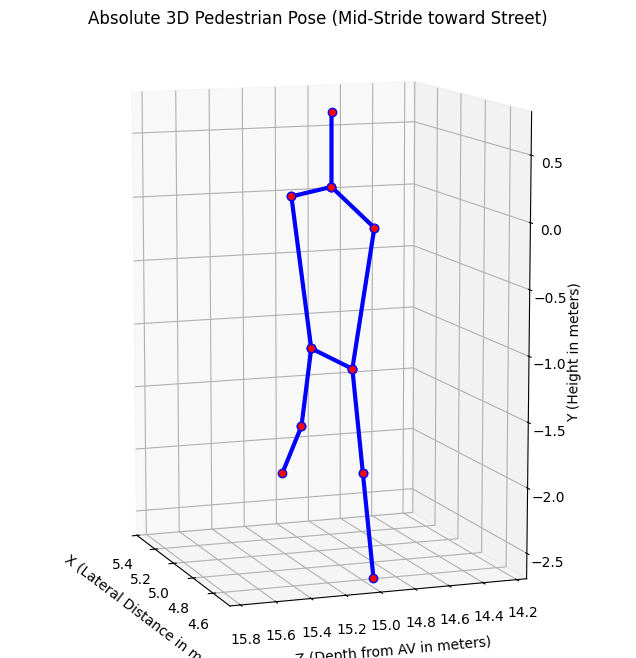

In [2]:
from mpl_toolkits.mplot3d import Axes3D

pose_2d_pixels = {
    "head": [900, 320],
    "neck": [900, 350],
    "left_shoulder": [880, 360],
    "right_shoulder": [920, 360],
    "left_hip": [890, 420],
    "right_hip": [910, 420],
    "left_knee": [885, 460],
    "right_knee": [915, 455], # Right leg slightly raised (mid-stride)
    "left_ankle": [880, 500],
    "right_ankle": [925, 480] # Right foot forward
}

#The intrinsic matrix 
fx,fy = 800.0,800.0
cx,cy = 640.0,360.0
K = np.array([
    [fx,  0, cx],
    [ 0, fy, cy],
    [ 0,  0,  1]
])

#The inverse intrinsic matrix for reverse projection
K_inv = np.linalg.inv(K)

# DEPTH SAMPLING & REVERSE PROJECTION
pose_3d_meters = {}

# In a real pipeline, we would sample the Z value from the LiDAR depth map at pixel (u,v).
# Here, we simulate sampling a depth of ~15 meters (from our Phase 1 setup).

simulated_depth = 15.0


for joint, (u,v) in pose_2d_pixels.items():
    #Step A: Create a homogenous 2D pixel coordinate [u,v,1]
    pixel_coord = np.array([u,v,1.0])

    #Step B: Multiply by inverse intrinsic matrxi and scale by depth
    # Equation: [X, Y, Z] = Z * (K^-1 * [u, v, 1]^T)
    normalized_3d = K_inv @ pixel_coord
    absolute_3d = normalized_3d * simulated_depth

    pose_3d_meters[joint] = absolute_3d
    print(f"  {joint.ljust(15)}: Pixel({u}, {v}) -> 3D({absolute_3d[0]:.2f}m, {absolute_3d[1]:.2f}m, {absolute_3d[2]:.2f}m)")


#3D SKELETON RECONSTRUCTION & VISUALIZATION
#define the skeletal cconnections for drawing
skeleton_connections = [
    ("head", "neck"),
    ("neck", "left_shoulder"), ("neck", "right_shoulder"),
    ("left_shoulder", "left_hip"), ("right_shoulder", "right_hip"),
    ("left_hip", "right_hip"),
    ("left_hip", "left_knee"), ("right_hip", "right_knee"),
    ("left_knee", "left_ankle"), ("right_knee", "right_ankle")

]

fig = plt.figure(figsize=(10,8))    
ax = fig.add_subplot(111,projection='3d')

#plot the bones
for joint1, joint2 in skeleton_connections:
    p1 = pose_3d_meters[joint1]
    p2 = pose_3d_meters[joint2]

    # Note: In AV coordinate systems, X is right/left, Y is up/down (often inverted), Z is forward depth.
    # We invert Y for standard plotting visualization so the head is at the top.
    ax.plot([p1[0], p2[0]], [p1[2], p2[2]], [-p1[1], -p2[1]], color='blue', linewidth=3, marker='o', markersize=6, markerfacecolor='red')

#Set view angles to simulate looking at the pedestrian from the AV's perspective
ax.view_init(elev=10, azim=160)

ax.set_xlabel('X (Lateral Distance in meters)')
ax.set_ylabel('Z (Depth from AV in meters)')
ax.set_zlabel('Y (Height in meters)')
ax.set_title("Absolute 3D Pedestrian Pose (Mid-Stride toward Street)")

#Force equal aspect ratio for realistic proportions
ax.set_box_aspect((1,1,1.5))
plt.show()


## 🕸️ Phase 3: The Scene Context Graph (GNN)

We now know exactly how the pedestrian is standing (Phase 2), but why are they standing like that?

Humans do not move randomly. A pedestrian's trajectory is constrained by the geometry of the street (crosswalks, curbs) and the social pressure of other dynamic agents (approaching cars, other walking pedestrians). 
To feed this complex web of constraints into a neural network, we encode reality into a Graph Neural Network (GNN).

## The Concept: Nodes, Edges, and Adjacency
In our GNN, the world is reduced to two concepts:

Nodes: The "actors" in the scene. The AV itself, the pedestrian, a parked car, and the crosswalk geometry.

Edges: The physical distance (and sometimes relative velocity) between these nodes.

If the distance between the AV (Node 0) and the Pedestrian (Node 1) is shrinking rapidly, the "edge weight" between them increases, signaling to the network that this relationship is currently the most critical factor for predicting the future.

Before we look at the Python code, try dragging the nodes in this interactive graph to see how shifting the positions of the AV, the Pedestrian, and the Crosswalk changes the edge weights (distances) that feed into the neural network:

Calculating Spatial Edges (Euclidean Distance)
[[ 0.   15.75 16.92 25.18]
 [15.75  0.    1.22 12.68]
 [16.92  1.22  0.   12.38]
 [25.18 12.68 12.38  0.  ]]


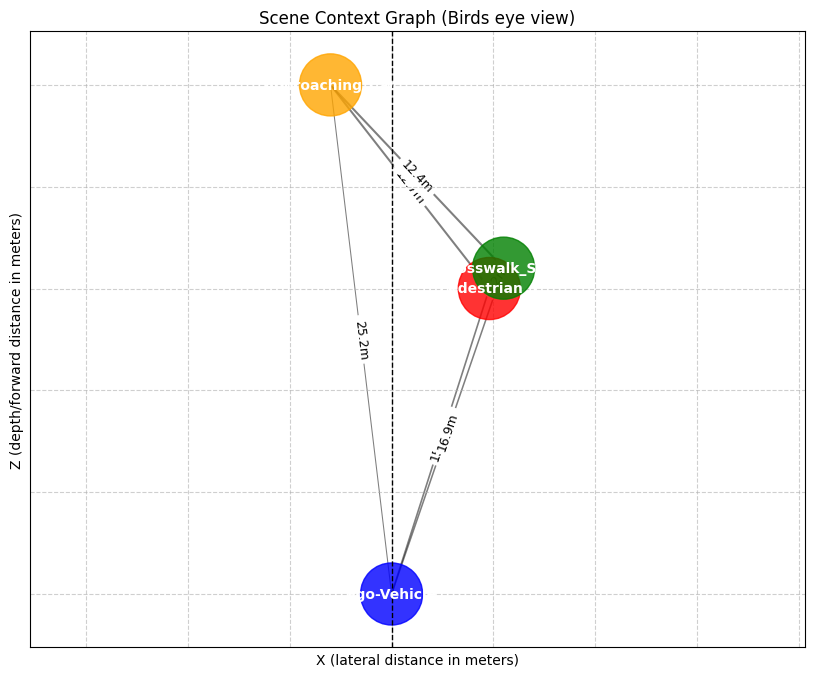

In [3]:
#intution class cruise ship tk
import networkx as nx

#DEFINE THE NODES
# From Phase 2, our pedestrian's center of mass is roughly:
# X (Lateral) = 4.8m right of the car, Z (Depth) = 15.0m ahead.
# We will use top-down (BEV - Bird's Eye View) coordinates for the graph: (X, Z)

nodes = {
    0: {"type": "Ego-Vehicle", "pos": np.array([0.0, 0.0])},
    1: {"type": "Pedestrian_1", "pos": np.array([4.8, 15.0])},
    2: {"type": "Crosswalk_Start", "pos": np.array([5.5, 16.0])},
    3: {"type": "Approaching_Car", "pos": np.array([-3.0, 25.0])} # Car in oncoming lane
}

num_nodes = len(nodes)

#BUILD THE SPATIAL ADJACENCY MATRIX
# An adjacency matrix is an N x N matrix where row i and column j represent 
# the distance (edge weight) between Node i and Node j.

adjacency_matrix = np.zeros((num_nodes,num_nodes))

print('Calculating Spatial Edges (Euclidean Distance)')

for i in range(num_nodes):
    for j in range(num_nodes):
        if i == j:
            adjacency_matrix[i][j] = 0.0
        else:
            #Calculate euclidean distance
            dist = np.linalg.norm(nodes[i]['pos'] - nodes[j]['pos'])
            adjacency_matrix[i][j] = dist

print(np.round(adjacency_matrix,2))

#Visualize the Scene Graph

G = nx.Graph()

#Add nodes with their physical positions
for node_id, data in nodes.items():
    G.add_node(node_id, pos=(data['pos'][0],data['pos'][1]), label=data['type'])

#ADd edges with distance weights
for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        weight = adjacency_matrix[i][j]
        # In GNNs, closer objects usually have stronger connections. 
        # We invert distance for visual line thickness (closer = thicker line)
        G.add_edge(i,j,weight=weight, thickness=max(0.5,20.0 / (weight + 1)))

#Plotting setup
plt.figure(figsize=(10,8))
pos = nx.get_node_attributes(G, 'pos')

#Draw the nodes
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color=['blue','red','green','orange'],alpha=0.8)

#Draw the edges
edges = G.edges()
thickness = [G[u][v]['thickness'] for u, v in edges]
nx.draw_networkx_edges(G, pos, width=thickness,alpha=0.5)

#Add labels
labels = nx.get_node_attributes(G,'label')
nx.draw_networkx_labels(G, pos,labels,font_size=10,font_weight='bold', font_color='white')


#Add edge weight labels(distances)
edge_labels = {(u, v): f"{G[u][v]['weight']:.1f}m" for u, v in edges}
nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels,font_size=9)

#Format the plot to look like a top-down street view
plt.title('Scene Context Graph (Birds eye view)')
plt.xlabel('X (lateral distance in meters)')
plt.ylabel('Z (depth/forward distance in meters)')
plt.grid(True, linestyle='--',alpha=0.6)
plt.axvline(x=0, color='black',linewidth=1, linestyle='--')
plt.axis('equal')
plt.show()


## 🧠 Phase 4: Transformer Forecasting & Uncertainty Head (GMM)

This is the brain of the operation. We have extracted the 3D pose (Phase 2) and mapped the social pressure via a Scene Graph (Phase 3). Now, we must predict the future.

In older AV systems, models output a single, deterministic trajectory (e.g., "The pedestrian will be exactly at X=5, Z=12 in 3 seconds"). This is incredibly dangerous. If the model is wrong, the car hits someone.

Modern architectures use a Gaussian Mixture Model (GMM) at the output layer. Instead of one line, the model outputs multiple possible futures (multi-modal paths), each with a probability score and an expanding circle of spatial uncertainty (variance)

## The Concept: GMMs in Trajectory Prediction

A Gaussian Mixture Model represents a combination of normal distributions (bell curves). In 2D space, a normal distribution looks like a heat-map circle.

If we predict $K=2$ modes (two possible futures):

Mode 1 (Crosses Street): High probability ($\pi_1 = 0.75$), but higher spatial variance ($\sigma_1$) because human walking speed varies. The heatmap stretches out.

Mode 2 (Stops at Curb): Lower probability ($\pi_2 = 0.25$), but very tight spatial variance ($\sigma_2$) because if they stop, we know exactly where they will be. The heatmap is small and dense.

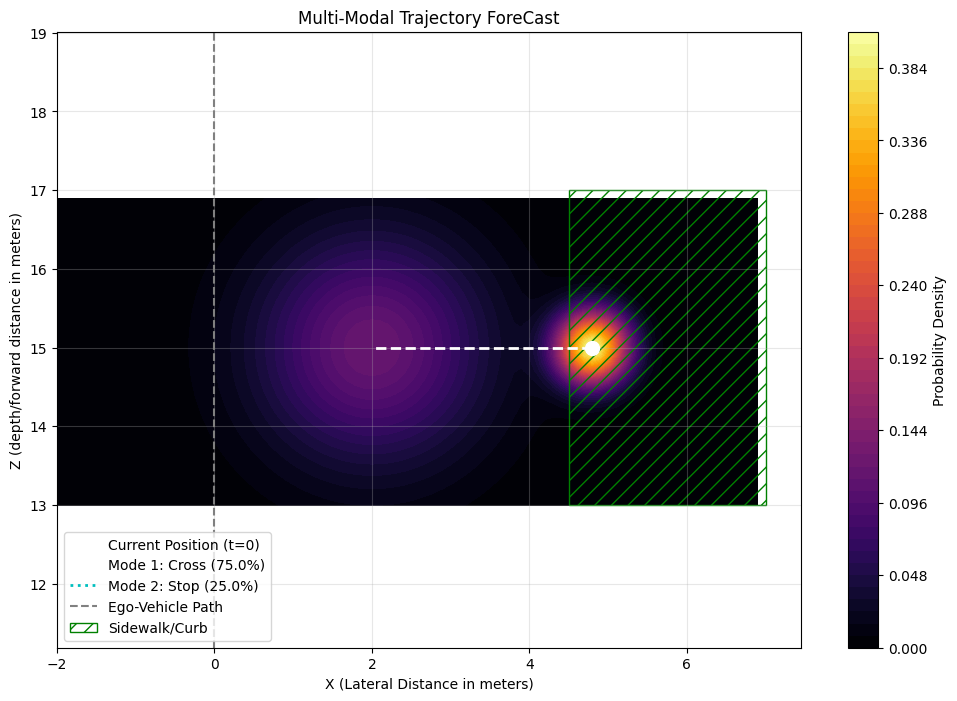


✅ Phase 4 Complete. Uncertainty has been mathematically modeled.


In [4]:
from scipy.stats import multivariate_normal
import matplotlib.patches as patches

#SIMULATE TRANSFORM OUTPUT(the future prediction)
# Our Pedestrian is currently at (X=4.8, Z=15.0).
# We are forecasting 3 seconds into the future, at 1-second intervals (t=1, t=2, t=3).
future_timestamps = [1,2,3]

# The neural network outputs parameters for a Gaussian Mixture Model (K=2 modes)
# Mode 1: Intends to cross the street (High probability)
# Mode 2: Intends to stop at the curb (Lower probability)

gmm_output = {
    "mode_1": {
        "probability": 0.75, # 75% chance they cross
        "predictions": [
            # [mean_X, mean_Z, variance_X, variance_Z]
            [4.0, 15.0, 0.2, 0.2],  # t=1: Stepping into road
            [3.0, 15.0, 0.5, 0.5],  # t=2: Mid-lane (variance grows)
            [2.0, 15.0, 1.0, 1.0]   # t=3: Far lane (high uncertainty)
        ]
    },
    "mode_2": {
        "probability": 0.25, # 25% chance they stop at the curb
        "predictions": [
            [4.8, 15.0, 0.1, 0.1],  # t=1: Pausing
            [4.8, 15.0, 0.1, 0.1],  # t=2: Still standing
            [4.8, 15.0, 0.1, 0.1]   # t=3: Still standing (very tight variance)
        ]
    }
}


#RENDER THE PROBABILITY DENSITY
#Create a grid representing out street
x_grid, z_grid = np.mgrid[-2:7:0.1, 13:17:0.1]
grid_coords = np.empty(x_grid.shape + (2,))
grid_coords[:,:,0] = x_grid
grid_coords[:,:,1] = z_grid

#we will calculate the probability density function for the final timestep
pdf_total = np.zeros(x_grid.shape)

for mode_name, data in gmm_output.items():
    prob = data['probability']
    final_pred = data['predictions'][2]

    mean = [final_pred[0], final_pred[1]]
    #Covariance matrix
    cov = [[final_pred[2], 0],[0,final_pred[3]]]

    #generate the gaussian distribution for this mode
    rv = multivariate_normal(mean,cov)

    #ADd it to the total probability map, weighted by the mode's probability
    pdf_total += prob * rv.pdf(grid_coords)

#VISUALIZE THE FUTURE
plt.figure(figsize=(12,8))

#Draw the probability heatmap
contour = plt.contourf(x_grid, z_grid, pdf_total, levels=50,cmap='inferno')
cbar = plt.colorbar(contour)
cbar.set_label('Probability Density')

#Draw the starting position
start_pos = [4.8,15.0]
plt.plot(start_pos[0],start_pos[1],'wo',markersize=10,label='Current Position (t=0)')

#Draw the predicted mean trajectories over time
#Mode 1 path
mode1_x = [start_pos[0]] + [p[0] for p in gmm_output['mode_1']['predictions']]
mode1_z = [start_pos[1]] + [p[1] for p in gmm_output["mode_1"]["predictions"]]
plt.plot(mode1_x, mode1_z, 'w--', linewidth=2, label=f'Mode 1: Cross ({gmm_output["mode_1"]["probability"]*100}%)')

#Mode 2 path
mode2_x = [start_pos[0]] + [p[0] for p in gmm_output["mode_2"]["predictions"]]
mode2_z = [start_pos[1]] + [p[1] for p in gmm_output["mode_2"]["predictions"]]
plt.plot(mode2_x, mode2_z, 'c:', linewidth=2, label=f'Mode 2: Stop ({gmm_output["mode_2"]["probability"]*100}%)')

#Draw environmental context
plt.axvline(x=0, color='gray',linestyle='--', label='Ego-Vehicle Path')
rect = patches.Rectangle((4.5,13), 2.5,4, linewidth=1, edgecolor='green', facecolor='none',hatch='//',label='Sidewalk/Curb')
plt.gca().add_patch(rect)

plt.title('Multi-Modal Trajectory ForeCast')
plt.xlabel('X (Lateral Distance in meters)')
plt.ylabel('Z (depth/forward distance in meters)')
plt.legend(loc='lower left')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print("\n✅ Phase 4 Complete. Uncertainty has been mathematically modeled.")

## 🛑 Phase 5: Motion Planning & The AV HUD

Everything we have built so far—sensor fusion, pose extraction, scene graphs, and trajectory forecasting, has been to answer one question: "What is the world doing?"

Now, the AV must answer the final question: "What do I do about it?"

This is the job of the Motion Planner. The planner takes the multi-modal probability map from Phase 4 and calculates a Cost Function for its own potential trajectories. If the pedestrian's 75% probability path intersects the AV's intended path within a critical Time-To-Collision (TTC) window, the planner overrides the cruise control and initiates a braking sequence.

## The Concept: Risk Envelopes and Braking

Autonomous vehicles do not slam on the brakes the second a pedestrian looks at the road. They calculate a smooth deceleration curve based on the expanding Gaussian uncertainty we modeled in Phase 4.

Calculating Intersection Risk...
Decision Output: MAINTAIN SPEED


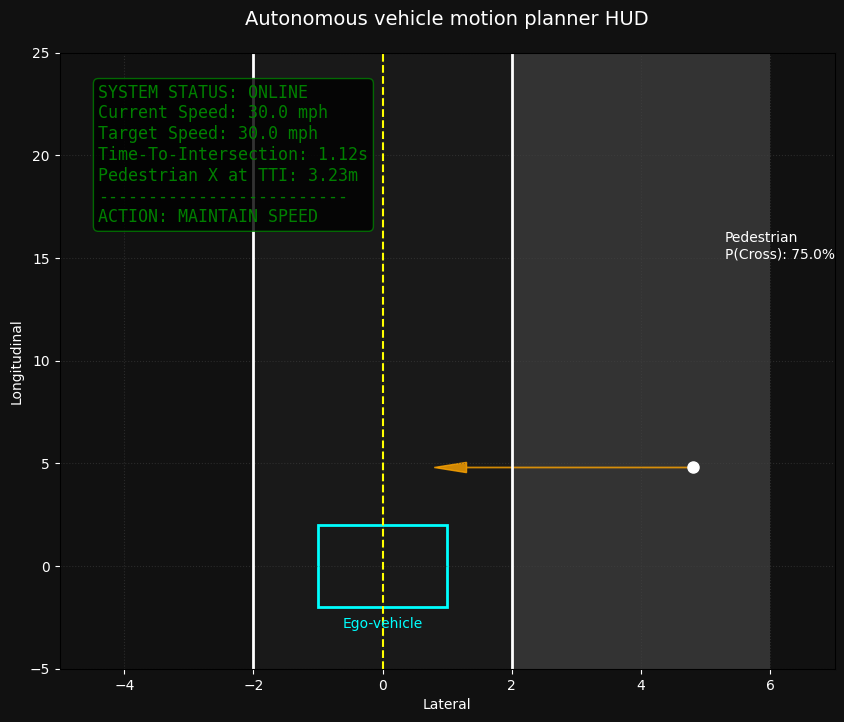

In [6]:
#THE DATA PAYLOAD
#Our AV is traveling at 13.4 m/s (roughly 30 mph)
av_speed_mps = 13.4
av_pos_z = 0.0

#Pedestrian data from our GMM forecast
ped_x = 4.8
ped_z = 15.0
cross_probability = 0.75
ped_speed_mps = 1.4

#THE MOTION PLANNER LOGIc
print('Calculating Intersection Risk...')

#how long until the AV reachers the pedestrian's Z-Depth
time_to_reach_z = (ped_z - av_pos_z) / av_speed_mps

#How far into the street will the pedestrian be at that exact time?
#Assuming they move directly left toward x=0
projected_ped_x = ped_x - (ped_speed_mps * time_to_reach_z)

#Collision logic gate:
#If probability is high and they will be in our lane
in_lane = -2.0 < projected_ped_x < 2.0
is_likely = cross_probability > 0.50

if in_lane and is_likely:
    decision = 'YIELD / BRAKING ENGAGED'
    color = 'red'
    target_speed = 0.0
else:
    decision = 'MAINTAIN SPEED'
    color = 'green'
    target_speed = av_speed_mps

print(f'Decision Output: {decision}')

#RENDER THE ENGINEERING HUD
fig, ax = plt.subplots(figsize=(10,8), facecolor='#111111')
ax.set_facecolor('#111111')

#Draw road 
ax.axvline(x=-2, color='white',linestyle='-', linewidth=2)
ax.axvline(x=2, color='white',linestyle='-',linewidth=2)
ax.axvline(x=0, color='yellow',linestyle='--',linewidth=1.5)
ax.fill_between([-2,2],-5,25,color="#222222",alpha=0.5)

#Draw sidewalk
rect = patches.Rectangle((2, -5), 4, 30, linewidth=0, facecolor='#333333')
ax.add_patch(rect)

#Draw AV
av_rect = patches.Rectangle((-1,-2),2,4,linewidth=2,edgecolor='cyan',facecolor='none')
ax.add_patch(av_rect)
ax.text(0, -3, 'Ego-vehicle',color='cyan',ha='center',fontsize=10)

#Draw pedestrian
ax.plot(ped_x, ped_x, 'wo',markersize=8)
ax.text(ped_x + 0.5, ped_z, f"Pedestrian\nP(Cross): {cross_probability*100}%", color='white', fontsize=10)

#Draw forecasted path
ax.arrow(ped_x, ped_x, -ped_speed_mps * 2.5,0, head_width=0.5, head_length=0.5, fc='orange',ec='orange',alpha=0.8)

#HUD OVERLAY TEXT
hud_text = (
    f"SYSTEM STATUS: ONLINE\n"
    f"Current Speed: {av_speed_mps * 2.237:.1f} mph\n"
    f"Target Speed: {target_speed * 2.237:.1f} mph\n"
    f"Time-To-Intersection: {time_to_reach_z:.2f}s\n"
    f"Pedestrian X at TTI: {projected_ped_x:.2f}m\n"
    f"-------------------------\n"
    f"ACTION: {decision}")

#Place HUD box on the screen
props = dict(boxstyle='round',facecolor='black',alpha=0.8, edgecolor=color)
ax.text(0.05,0.95, hud_text, transform=ax.transAxes, fontsize=12,verticalalignment='top', color=color, bbox=props, fontfamily='monospace')

#Formatting
ax.set_xlim(-5,7)
ax.set_ylim(-5,25)
ax.set_title('Autonomous vehicle motion planner HUD', color='white',fontsize=14,pad=20)
ax.set_xlabel('Lateral',color='white')
ax.set_ylabel('Longitudinal',color='white')
ax.tick_params(colors='white')
plt.grid(True, color='#444444',linestyle=':',alpha=0.5)
plt.show()




## The Journey Complete

We see a dark-themed engineering dashboard. The mathematical models from the previous four phases have been distilled into a simple, binary command: YIELD.

Over these five phases, we built the entire logical pipeline of a modern autonomous vehicle:

Sensor Fusion (Phase 1): We mapped 2D pixels to 3D LiDAR space.

Pose Estimation (Phase 2): We extracted human skeleton kinematics to understand body language.

Graph Neural Networks (Phase 3): We mapped spatial relationships into an adjacency matrix.

Trajectory Forecasting (Phase 4): We predicted multi-modal Gaussian futures.

Motion Planning (Phase 5): We calculated intersecting risk and commanded the vehicle to brake.